# Cryptocurrency Historical Prices ML Project

## Name: Sudhanshu Ranjan

## Project: Cryptocurrency Historical Prices Prediction

## Dataset: Cryptocurrency Historical Prices Dataset

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load Dataset
df = pd.read_csv("/content/dataset.csv")

# Display first 5 rows
df.head()

,Unnamed: 0,open,high,low,close,volume,marketCap,timestamp,crypto_name,date
0,0,112.900002,118.800003,107.142998,115.910004,0.0,1.288693e+09,2013-05-05T23:59:59.999Z,Bitcoin,2013-05-05
1,1,3.493130,3.692460,3.346060,3.590890,0.0,6.229819e+07,2013-05-05T23:59:59.999Z,Litecoin,2013-05-05
2,2,115.980003,124.663002,106.639999,112.300003,0.0,1.249023e+09,2013-05-06T23:59:59.999Z,Bitcoin,2013-05-06
3,3,3.594220,3.781020,3.116020,3.371250,0.0,5.859436e+07,2013-05-06T23:59:59.999Z,Litecoin,2013-05-06
4,4,112.250000,113.444000,97.699997,111.500000,0.0,1.240594e+09,2013-05-07T23:59:59.999Z,Bitcoin,2013-05-07


In [6]:
# Dataset Information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72946 entries, 0 to 72945
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Unnamed: 0   72946 non-null  int64  
 1   open         72946 non-null  float64
 2   high         72946 non-null  float64
 3   low          72946 non-null  float64
 4   close        72946 non-null  float64
 5   volume       72946 non-null  float64
 6   marketCap    72946 non-null  float64
 7   timestamp    72946 non-null  object 
 8   crypto_name  72946 non-null  object 
 9   date         72946 non-null  object 
dtypes: float64(6), int64(1), object(3)
memory usage: 5.6+ MB


In [7]:
# Statistical Summary
df.describe()

,Unnamed: 0,open,high,low,close,volume,marketCap
count,72946.000000,72946.000000,7.294600e+04,72946.000000,7.294600e+04,7.294600e+04,7.294600e+04
mean,36472.500000,870.194495,8.964124e+02,844.060640,8.712949e+02,2.207607e+09,1.474922e+10
std,21057.840705,5231.654470,5.398613e+03,5079.389387,5.235508e+03,9.617885e+09,7.501159e+10
min,0.000000,0.000000,1.022100e-10,0.000000,8.292000e-11,0.000000e+00,0.000000e+00
25%,18236.250000,0.167916,1.767999e-01,0.158630,1.682982e-01,8.320618e+06,1.860432e+08
50%,36472.500000,1.630666,1.717542e+00,1.541486,1.640219e+00,1.098756e+08,1.268539e+09
75%,54708.750000,26.070557,2.756868e+01,24.791776,2.625195e+01,6.691398e+08,5.118618e+09
max,72945.000000,67549.735581,1.621883e+05,66458.723733,6.756683e+04,3.509679e+11,1.274831e+12


In [8]:
# Missing Values
df.isnull().sum()

,0
Unnamed: 0,0
open,0
high,0
low,0
close,0
volume,0
marketCap,0
timestamp,0
crypto_name,0
date,0


In [10]:
# Check Duplicate Values
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


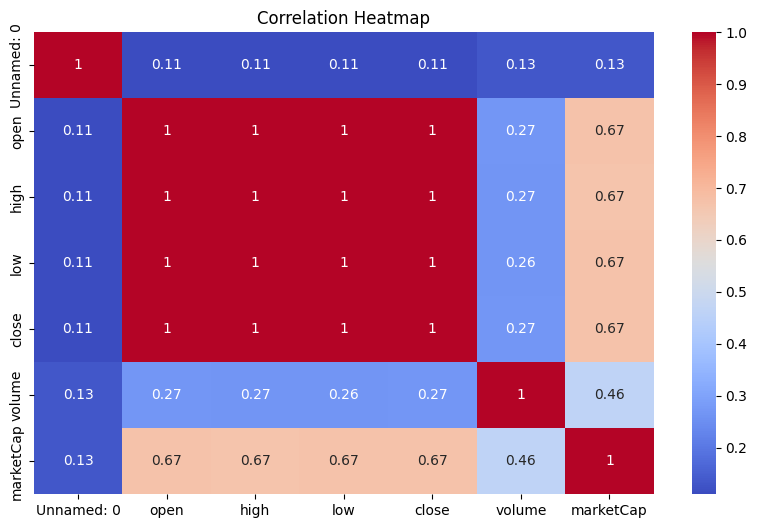

In [11]:
# Correlation Heatmap
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.heatmap(
    df.select_dtypes(include=['float64','int64']).corr(),
    annot=True,
    cmap='coolwarm'
)
plt.title("Correlation Heatmap")
plt.show()

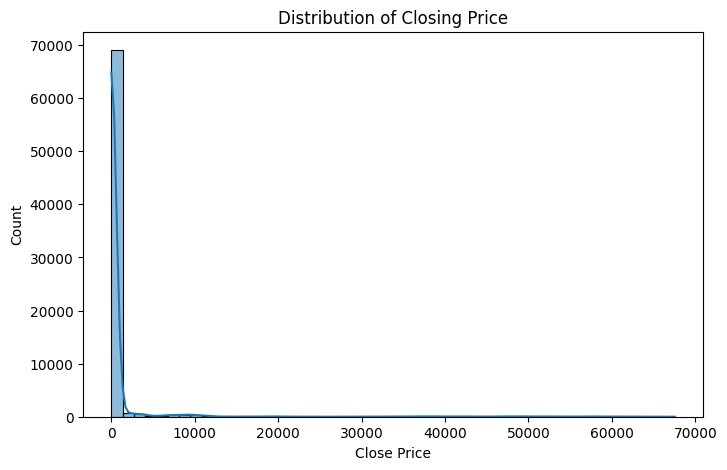

In [12]:
# Closing Price Distribution

plt.figure(figsize=(8,5))
sns.histplot(df['close'], bins=50, kde=True)
plt.title("Distribution of Closing Price")
plt.xlabel("Close Price")
plt.show()

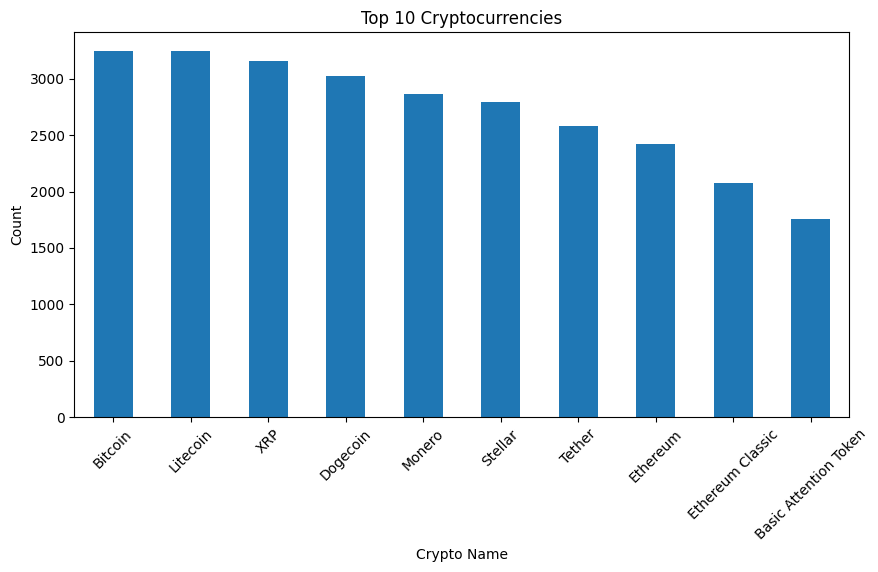

In [13]:
# Top 10 Cryptocurrencies by Records

plt.figure(figsize=(10,5))
df['crypto_name'].value_counts().head(10).plot(kind='bar')
plt.title("Top 10 Cryptocurrencies")
plt.xlabel("Crypto Name")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

In [14]:
# Feature Engineering

# Daily Price Change
df['price_change'] = df['close'] - df['open']

# Daily Volatility
df['volatility'] = (df['high'] - df['low']) / df['open']

# 7-Day Moving Average
df['ma7'] = df['close'].rolling(window=7).mean()

# Fill missing values created by rolling
df['ma7'] = df['ma7'].fillna(df['ma7'].mean())

df.head()

,Unnamed: 0,open,high,low,close,volume,marketCap,timestamp,crypto_name,date,price_change,volatility,ma7
0,0,112.900002,118.800003,107.142998,115.910004,0.0,1.288693e+09,2013-05-05T23:59:59.999Z,Bitcoin,2013-05-05,3.010002,0.103251,871.363736
1,1,3.493130,3.692460,3.346060,3.590890,0.0,6.229819e+07,2013-05-05T23:59:59.999Z,Litecoin,2013-05-05,0.097760,0.099166,871.363736
2,2,115.980003,124.663002,106.639999,112.300003,0.0,1.249023e+09,2013-05-06T23:59:59.999Z,Bitcoin,2013-05-06,-3.680000,0.155398,871.363736
3,3,3.594220,3.781020,3.116020,3.371250,0.0,5.859436e+07,2013-05-06T23:59:59.999Z,Litecoin,2013-05-06,-0.222970,0.185019,871.363736
4,4,112.250000,113.444000,97.699997,111.500000,0.0,1.240594e+09,2013-05-07T23:59:59.999Z,Bitcoin,2013-05-07,-0.750000,0.140258,871.363736


In [15]:
# Feature Selection

features = [
    'open',
    'high',
    'low',
    'volume',
    'marketCap',
    'price_change',
    'ma7'
]

X = df[features]
y = df['volatility']

print(X.shape)
print(y.shape)

(72946, 7)
(72946,)


In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

Training Shape: (58356, 7)
Testing Shape: (14590, 7)


In [17]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Scaling Completed Successfully")

Scaling Completed Successfully


In [19]:
import numpy as np

# Replace infinite values with NaN
df.replace([np.inf, -np.inf], np.nan, inplace=True)

# Remove rows containing NaN
df.dropna(inplace=True)

# Create X and y again
features = [
    'open',
    'high',
    'low',
    'volume',
    'marketCap',
    'price_change',
    'ma7'
]

X = df[features]
y = df['volatility']

print("Dataset Shape:", X.shape)

Dataset Shape: (72944, 7)


In [20]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

print("✅ Model Training Completed")

✅ Model Training Completed


In [21]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Prediction
y_pred = model.predict(X_test)

# Evaluation
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Model Evaluation Results")
print("------------------------")
print("MAE :", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

Model Evaluation Results
------------------------
MAE : 0.023747484619234212
RMSE: 0.1478063435253145
R2 Score: 0.19279402880090757


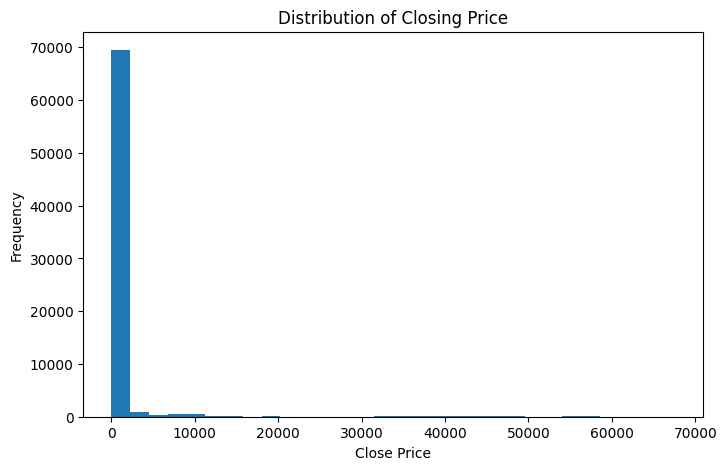

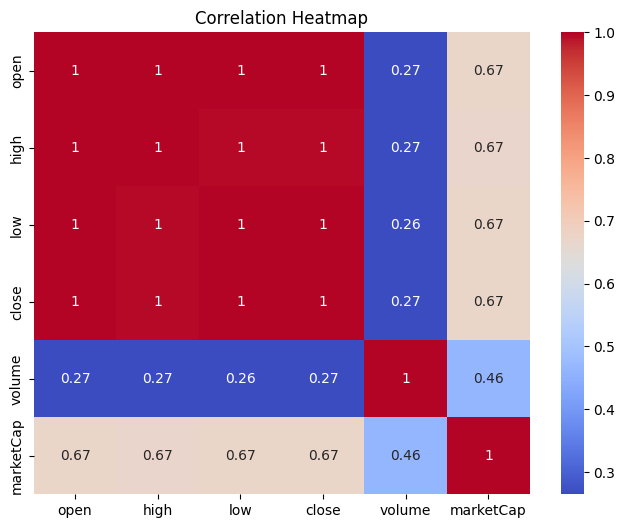

In [22]:
import matplotlib.pyplot as plt

# Histogram of Close Price
plt.figure(figsize=(8,5))
plt.hist(df['close'], bins=30)
plt.title("Distribution of Closing Price")
plt.xlabel("Close Price")
plt.ylabel("Frequency")
plt.show()

# Correlation Heatmap
import seaborn as sns

plt.figure(figsize=(8,6))
sns.heatmap(df[['open','high','low','close','volume','marketCap']].corr(),
            annot=True,
            cmap='coolwarm')

plt.title("Correlation Heatmap")
plt.show()

        Feature  Importance
5  price_change    0.283467
1          high    0.261912
2           low    0.167039
0          open    0.093199
6           ma7    0.081666
4     marketCap    0.064811
3        volume    0.047906


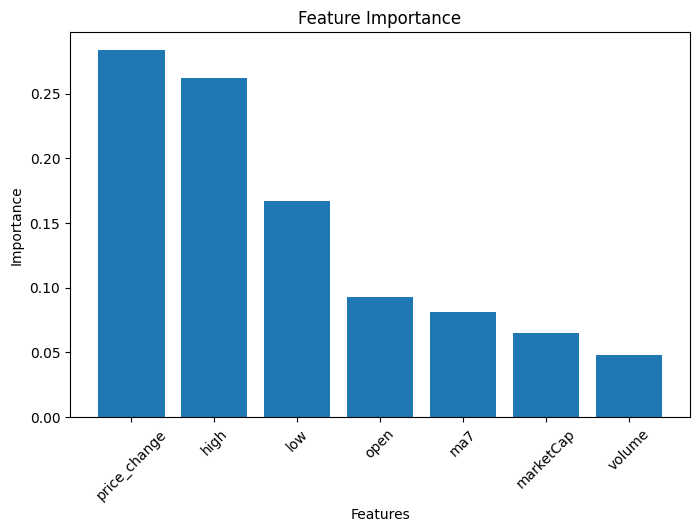

In [23]:
import pandas as pd
import matplotlib.pyplot as plt

# Feature Importance
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

importance = importance.sort_values(by='Importance', ascending=False)

print(importance)

# Plot
plt.figure(figsize=(8,5))
plt.bar(importance['Feature'], importance['Importance'])
plt.title("Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.xticks(rotation=45)
plt.show()

In [24]:
# Prediction on Test Data

y_pred = model.predict(X_test)

prediction_df = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

prediction_df.head(10)

,Actual,Predicted
0,0.028951,0.044733
1,0.042695,0.059488
2,0.084736,0.068309
3,0.000862,0.000847
4,0.103453,0.055658
5,0.012921,0.013289
6,0.043109,0.056013
7,0.030916,0.054649
8,0.111132,0.088558
9,0.014639,0.021720


In [25]:
# Save Predictions

prediction_df.to_csv("prediction_results.csv", index=False)

print("✅ prediction_results.csv saved successfully.")

✅ prediction_results.csv saved successfully.


In [26]:
print("="*50)
print("CRYPTOCURRENCY VOLATILITY PREDICTION PROJECT")
print("="*50)

print("\nDataset Shape :", df.shape)
print("Number of Features :", X.shape[1])
print("Training Samples :", X_train.shape[0])
print("Testing Samples :", X_test.shape[0])

print("\nModel Used : Random Forest Regressor")

print("\nEvaluation Metrics")
print("--------------------")
print("MAE :", mae)
print("RMSE :", rmse)
print("R2 Score :", r2)

print("\n✅ Project Completed Successfully")

CRYPTOCURRENCY VOLATILITY PREDICTION PROJECT

Dataset Shape : (72944, 13)
Number of Features : 7
Training Samples : 58355
Testing Samples : 14589

Model Used : Random Forest Regressor

Evaluation Metrics
--------------------
MAE : 0.023747484619234212
RMSE : 0.1478063435253145
R2 Score : 0.19279402880090757

✅ Project Completed Successfully


In [27]:
# Save Trained Model

import joblib

joblib.dump(model, "crypto_volatility_model.pkl")

print("✅ Model saved as crypto_volatility_model.pkl")

✅ Model saved as crypto_volatility_model.pkl
